<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [60]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [102]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model


import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [91]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [92]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [93]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [94]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

In [145]:
new_train['Satisfaction'].value_counts()

,count
Satisfaction,
0,463
1,387


## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [95]:
#함수 만들기
def build_model_input(data):

    # 1. 결측치 처리
    num_cols = data.select_dtypes(include=['number']).columns
    for col in num_cols:
        data[col].fillna(data[col].median(), inplace=True)

    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        data[col].fillna(data[col].mode()[0], inplace=True)

    # 2. 값 변경
    data['Satisfaction'] = data['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

    # 3. 변수 제거
    drop_cols = ['Unnamed: 0', 'ID']
    data.drop(columns=drop_cols, inplace=True)

    # 4. 라벨 인코딩
    cat_cols = ['Gender', 'Customer Type', 'Type of Travel',  'Class']
    for col in cat_cols:
        encoder = LabelEncoder()
        data[col] = encoder.fit_transform(data[col])

    # 5. 가변수화
    dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
                 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
                 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
    categories = [0, 1, 2, 3, 4, 5]
    for col in dumm_cols:
        data[col] = pd.Categorical(data[col], categories=categories)
    data = pd.get_dummies(data, columns=dumm_cols, drop_first=False, dtype=int)

    # 6. x, y 분리
    target = 'Satisfaction'
    x = data.drop(columns=target)
    y = data.loc[:, target]

    # 7. 스케일링
    x = scaler.transform(x)

    # 반환
    return x, y

## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [96]:
x_val, y_val = build_model_input(new_test)

# 확인
print(x_val.shape)
print(y_val.shape)

(350, 92)
(350,)


### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [97]:
y_pred = base_model.predict(x_val)

print(y_pred[:5])

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[3.1519553e-01]
 [2.0488458e-04]
 [3.1127080e-01]
 [9.9914634e-01]
 [2.7906374e-04]]


In [98]:
y_pred = np.where(y_pred >= 0.5, 1, 0)
print(y_pred[:5])

[[0]
 [0]
 [0]
 [1]
 [0]]


In [99]:
# 의견 : 오버 샘플링 적용 후 불만족 고객(0번)을 찾아내는 재현율(Recall)이 81%에서 83%로 향상되었으며,
#        전체적인 정확도(Accuracy) 또한 0.91로 개선되어 안정적인 성능을 보여주고 있습니다. 특히 1번 클래스의 재현율이 1.00에 달해 만족 고객을 완벽하게 식별해내면서도
#        클래스별 F1-score가 0.91로 균형 있게 나타나 모델의 신뢰도가 크게 높아졌습니다

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91       191
           1       0.83      1.00      0.91       159

    accuracy                           0.91       350
   macro avg       0.91      0.91      0.91       350
weighted avg       0.92      0.91      0.91       350



  오버 샘플링을 하기전 검증된 결과

                  precision    recall  f1-score   support

           0       0.99      0.81      0.89       191
           1       0.81      0.99      0.90       159

    accuracy                           0.89       350
    macro avg       0.90      0.90      0.89       350
    weighted avg       0.91      0.89      0.89       350

## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [100]:
x_train, y_train = build_model_input(new_train)

# 확인
print(x_train.shape)
print(y_train.shape)

(850, 92)
(850,)


### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [103]:
clear_session()

nfeatures = x_train.shape[1]

model1 = Sequential([
    Input(shape=(nfeatures,)),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 192 (768.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [104]:
model1.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [105]:
es = EarlyStopping(monitor='val_loss',
                   min_delta=0,
                   patience=10,
                   restore_best_weights=True,
                   verbose=1)

In [107]:
hist = model1.fit(x_train, y_train, epochs=100, validation_data=(x_val, y_val), batch_size=64, callbacks=[es], verbose=0).history

Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 27.


- 학습 곡선을 확인합니다.

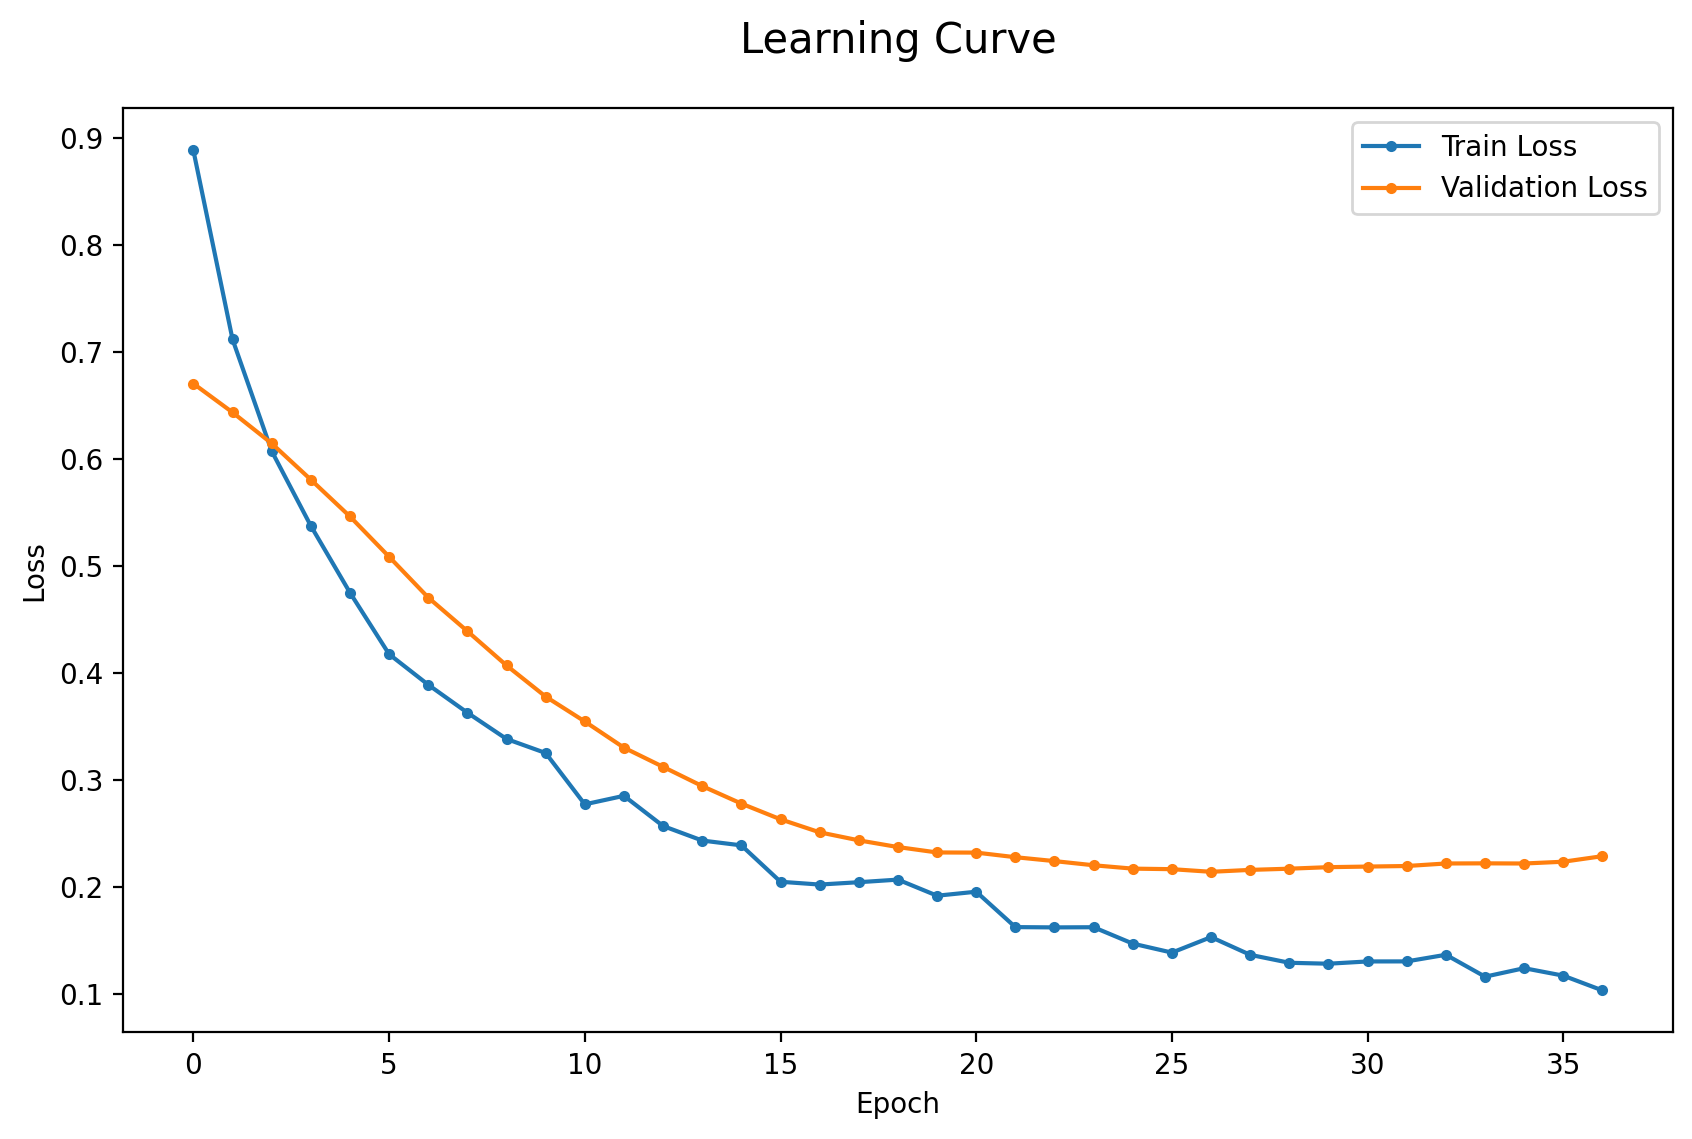

In [108]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [109]:
y_pred = model1.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [110]:
print(classification_report(y_val, y_pred))

# 의견 : 이번 추가 학습을 통해 0번 클래스의 리콜 지표가 0.94까지 높아지면서, 불만족 고객을 찾아내는 능력이
#        만족 고객 분류 성능과 대등한 수준으로 올라와 매우 이상적인 균형을 이루게 되었습니다. 학습 곡선인 러닝 커브를 살펴보면
#        훈련 손실과 검증 손실이 큰 격차나 교차 현상 없이 매끄럽고 안정적으로 하향 곡선을 그리며 수렴하고 있어,
#        모델이 과적합 없이 데이터의 핵심 특징을 잘 포착했음을 알 수 있습니다. 결과적으로 전체 정확도와 F1-score가 모두 0.93이라는 고른 수치를 기록한 만큼,
#        이 모델은 실제 현장 데이터에 적용했을 때도 충분히 신뢰할 수 있는 실전 성능을 발휘할 것으로 판단됩니다.

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       191
           1       0.92      0.91      0.92       159

    accuracy                           0.93       350
   macro avg       0.93      0.92      0.93       350
weighted avg       0.93      0.93      0.93       350



### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [113]:
# 메모리 정리
clear_session()

# 모델 선언
model2 = base_model

# 모델 요약
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,501 (103.52 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 17,540 (68.52 KB)

- 학습 방법을 설정하고 학습을 수행합니다.

In [114]:
model2.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [115]:
es = EarlyStopping(monitor='val_loss',
                   min_delta=0,
                   patience=10,
                   restore_best_weights=True,
                   verbose=1)

In [117]:
hist = model2.fit(x_train, y_train, epochs=100, validation_data=(x_val, y_val), batch_size=64, callbacks=[es], verbose=0).history

Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 5.


- 학습 곡선을 확인합니다.

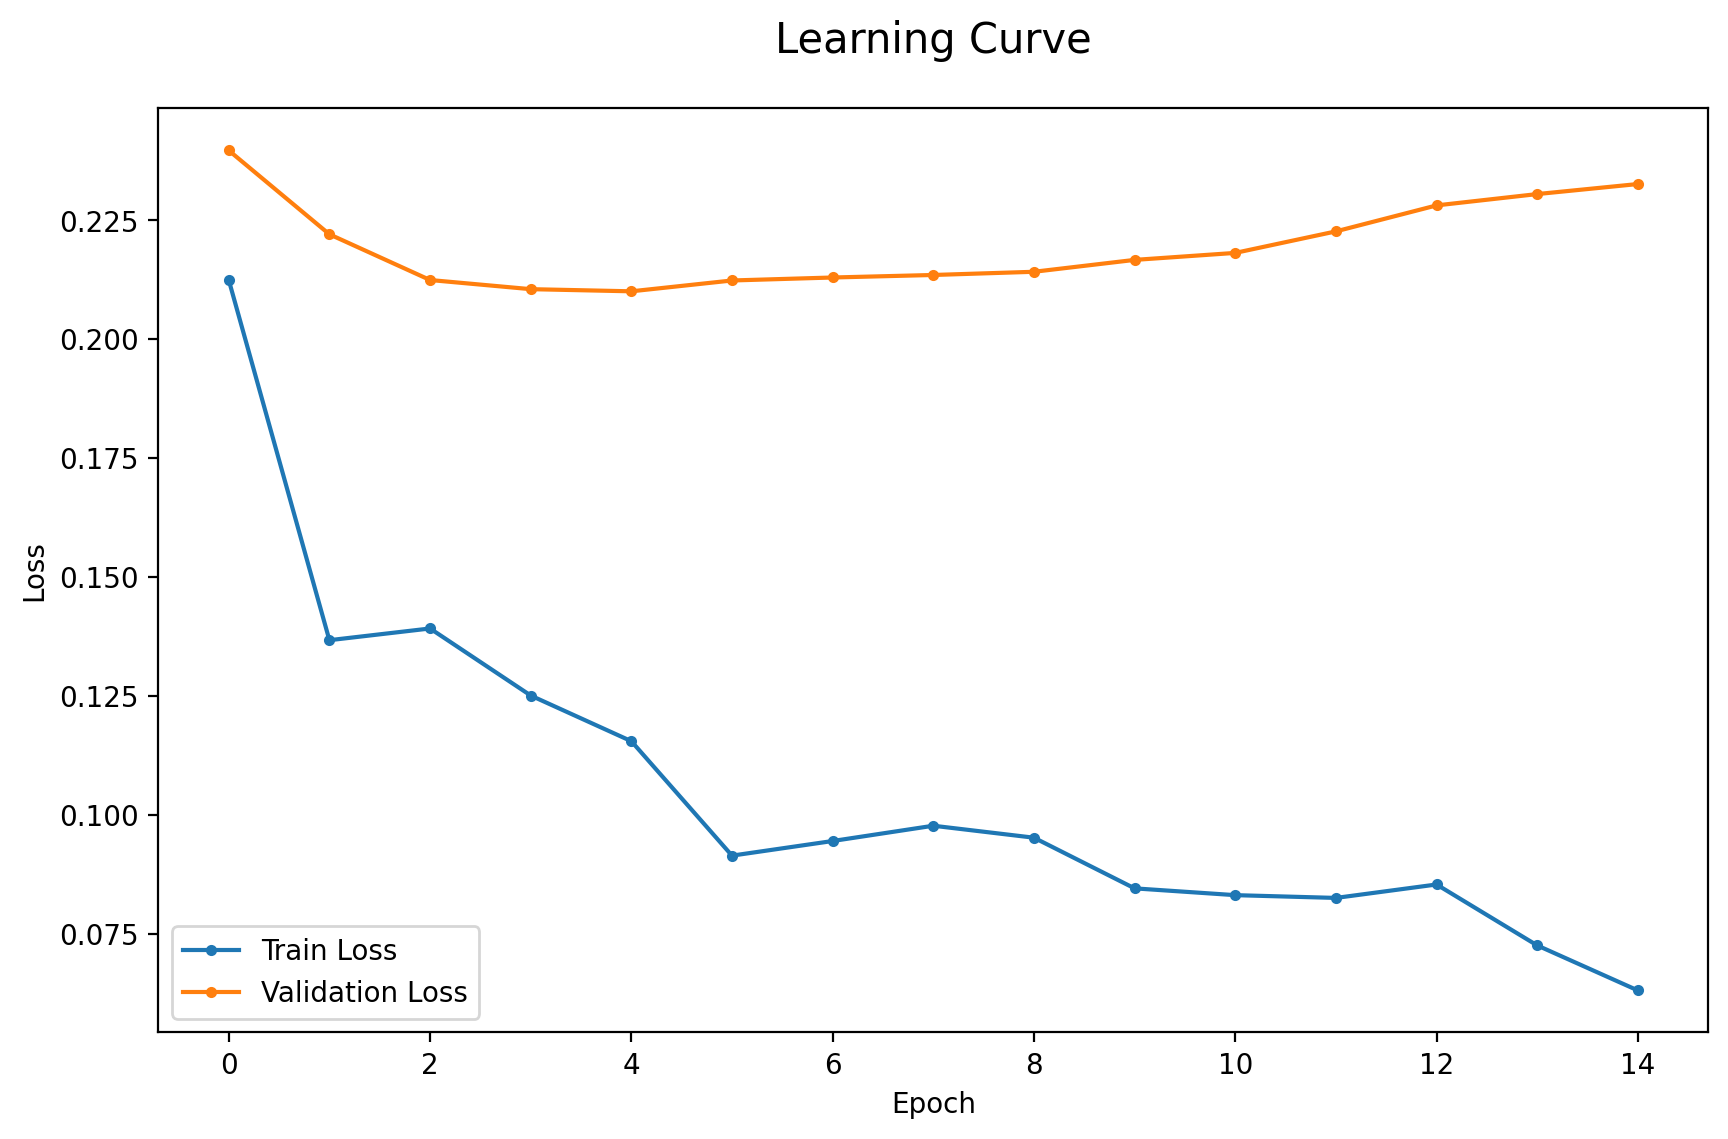

In [118]:
dl_history_plot(hist)


- 검증 데이터로 예측 및 평가를 수행합니다.

In [119]:
y_pred = model2.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [120]:
print(classification_report(y_val, y_pred))

# 의견 : 추가 학습 결과 0번 정밀도(0.95)와 1번 재현율(0.94) 등 전반적인 지표는 매우 우수합니다.
#        다만 학습 곡선에서 4 에포크 이후 검증 손실이 상승하는 전형적인 과적합 징후가 관찰되었습니다.
#        따라서 높은 수치에 안주하기보다 조기 종료나 규제 강화를 통해 모델의 일반화 성능을 확보하는 조정이 필요합니다.

              precision    recall  f1-score   support

           0       0.95      0.90      0.92       191
           1       0.89      0.94      0.91       159

    accuracy                           0.92       350
   macro avg       0.92      0.92      0.92       350
weighted avg       0.92      0.92      0.92       350



### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [137]:
# 메모리 정리
clear_session()

# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

# 마지막 레이어 제거
base_model.pop()

<Dense name=dense_3, built=True>

In [138]:
for layer in base_model.layers[:-3]:
    layer.trainable = False

model3 = Sequential([
    base_model,
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

- 학습 방법을 설정하고 학습을 수행합니다.

In [139]:
model3.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy')

In [140]:
es = EarlyStopping(monitor='val_loss',
                   min_delta=0.01,
                   patience=10,
                   restore_best_weights=True,
                   verbose=1)

In [141]:
hist = model3.fit(x_train, y_train, epochs=200, validation_data=(x_val, y_val), batch_size=64, callbacks=[es], verbose=0).history

Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 33.


- 학습 곡선을 확인합니다.

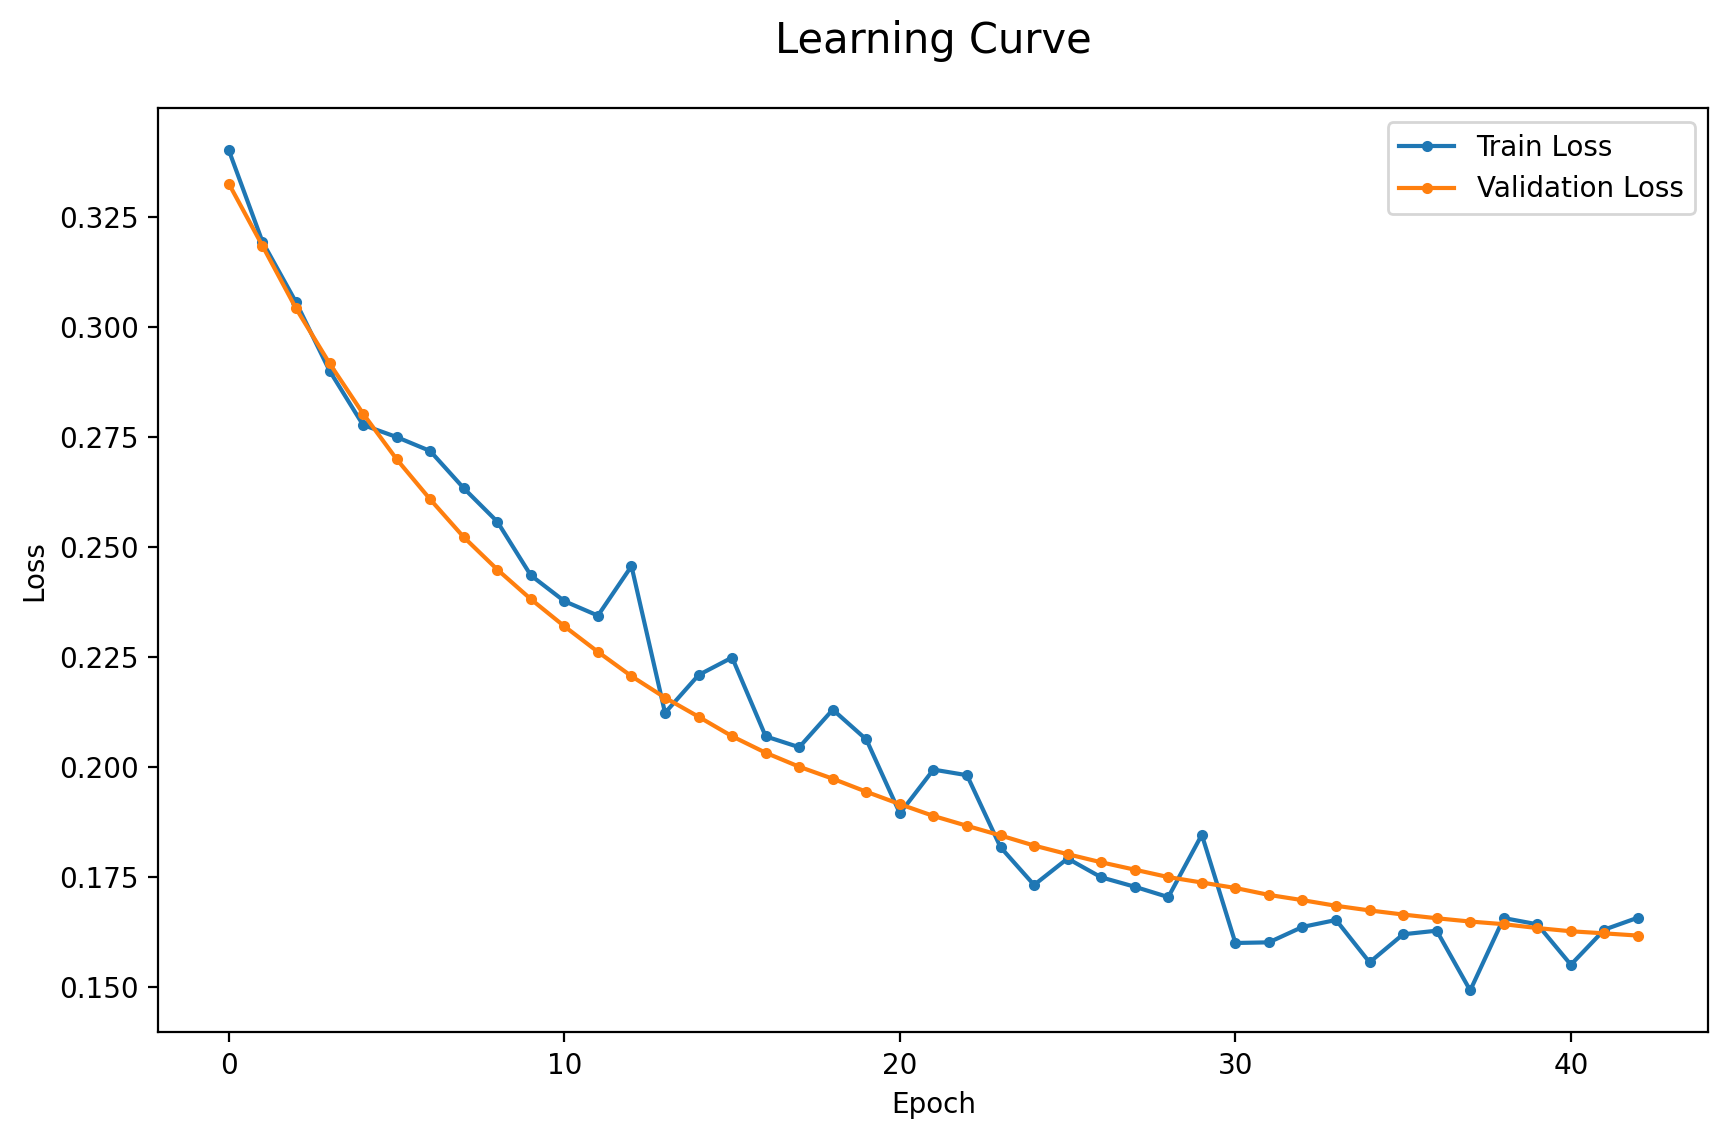

In [142]:
dl_history_plot(hist)


- 검증 데이터로 예측 및 평가를 수행합니다.

In [143]:
y_pred = model3.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [144]:
print(classification_report(y_val, y_pred))

# 의견 : 에폭 수를 충분히 확보한 결과, 1번 클래스의 재현율이 0.91까지 비약적으로 상승하며 특정 클래스에 치우치지 않는 0.93의
#        높은 정확도와 이상적인 밸런스를 달성했습니다. 학습 과정에서 검증 손실이 훈련 손실과 나란히 매끄럽게 수렴하며 과적합 없이
#        모델의 일반화 성능을 극대화하는 데 성공한 점이 고무적입니다. 모든 지표가 90%를 상회하는 고른 수치를 기록한 만큼,
#        이 모델은 실제 현장 데이터 적용 시에도 매우 높은 신뢰도를 보여줄 것으로 기대됩니다.

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       191
           1       0.94      0.91      0.92       159

    accuracy                           0.93       350
   macro avg       0.93      0.93      0.93       350
weighted avg       0.93      0.93      0.93       350



In [ ]:
# 종합적인 의견: 미세조정을 거친 최종 모델은 전체 정확도 0.93을 기록하며 초기화나 단순 추가학습 모델보다 정교한 예측력을 보여주었으며,
#                특히 클래스별 F1-score가 0.92와 0.94로 매우 균등하게 나타나 특정 데이터에 치우치지 않는 이상적인 밸런스를 확보했습니다.
#                기존 모델의 강점과 새로운 데이터의 특성이 조화롭게 반영되어 과적합 없이 안정적으로 수렴한 만큼, 실제 서비스 환경의 낯선 데이터가 입력되어도 높은 신뢰도를 유지할 것으로 판단됩니다.
#                결론적으로 정확도와 일반화 성능 모두에서 가장 우수한 수치를 기록한 미세조정 모델을 최종안으로 채택하는 것이 가장 효과적입니다.